<a href="https://colab.research.google.com/github/MachineLearning30110/MachineLearning-Models/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_blobs, make_circles, make_moons

X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

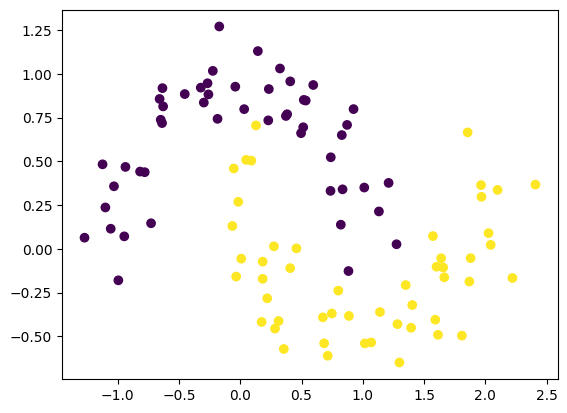

In [8]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [14]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

param_grid = {
    'svm__kernel':['linear', 'poly', 'rbf'],
    'svm__C':[0.1,1,10],
    'svm__gamma':[0.001,0.01,0.1]
}

In [29]:
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             param_grid={'svm__C': [0.1, 1, 10],
                         'svm__gamma': [0.001, 0.01, 0.1],
                         'svm__kernel': ['linear', 'poly', 'rbf']})

In [30]:
pred = grid.predict(X_test)

print(grid.best_params_)
print(accuracy_score(y_test,pred))

{'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
1.0


In [44]:
def plot_svm_boundary(model, X, y):
    plt.scatter(X[:,0], X[:,1], c=y)

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)

    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)

    plt.contour(XX, YY, Z, levels=[-1,0,1])

    plt.show()

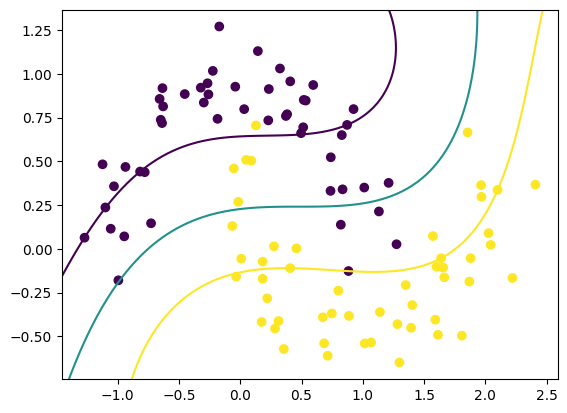

In [45]:
plot_svm_boundary(grid, X, y)